In [1]:
# importing necessary Python libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
#import plotly.offline as pyoff
import plotly.graph_objs as go 
#import plotly.figure_factory as ff

# avoid displaying warnings
import warnings
warnings.filterwarnings("ignore")

#import machine learning related libraries
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score, train_test_split, GridSearchCV, cross_validate
from multiscorer import MultiScorer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.cluster import KMeans
import time


try:
    import xgboost as xgb
except ImportError:
    print("Menginstal optuna...")
    !pip install xgboost
    import xgboost as xgb


In [2]:
df = pd.read_csv('../dataset/train_transaction_data.csv')
df.head()

,TransactionID,MemberID,Source,FK_PRODUCT_ID,FK_PROD_GRAM_ID,Qty,PricePerUnit,TransactionDatetime
0,ffd6c035bef03a2c386caf2552148fb2402b0b24,7ef72aa51aecb701dc5c4074480fcdf6,ELANG,27,52,1,NaN,2020-07-01 07:41:00 UTC
1,4fadf10aff7e250cc8d63badeaefdf383c0e1c13,577f1b9a093c2cec6398b1118f5d99ab,ALFAMART,22,39,1,290000.0,2020-07-01 07:24:00 UTC
2,7299df1aaf47b52017f58dd8e59df1fe37072670,e2ee74f248a74ed886a22f14348fbafd,EKTONG,22,39,1,263500.0,2020-07-01 09:13:00 UTC
3,22dae0e1e8bb87601eabd712721bd249739bc620,cefa8ef7469a8b4e6df3f745d4905000,CITRA,27,52,3,145000.0,2020-07-01 08:28:00 UTC
4,6a744d5d79e09b0c1646e604db1c4ec65eff73d7,5eecda17ddf06ed9d79f298b13f84785,INDOMARET,27,52,1,165900.0,2020-07-01 07:02:00 UTC


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130854 entries, 0 to 130853
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   TransactionID        130854 non-null  object 
 1   MemberID             130854 non-null  object 
 2   Source               130854 non-null  object 
 3   FK_PRODUCT_ID        130854 non-null  int64  
 4   FK_PROD_GRAM_ID      130854 non-null  int64  
 5   Qty                  130854 non-null  int64  
 6   PricePerUnit         111681 non-null  float64
 7   TransactionDatetime  130854 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 8.0+ MB


TransactionID              0
MemberID                   0
Source                     0
FK_PRODUCT_ID              0
FK_PROD_GRAM_ID            0
Qty                        0
PricePerUnit           19173
TransactionDatetime        0
dtype: int64

Karena hanya 14 persen maka buang saja baris datanya

In [4]:
np.round(df.isnull().sum()["PricePerUnit"]/df.MemberID.shape[0] * 100, 2)

14.65

In [5]:
df_data = df.dropna()
df_data.info()
df_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 111681 entries, 1 to 130853
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   TransactionID        111681 non-null  object 
 1   MemberID             111681 non-null  object 
 2   Source               111681 non-null  object 
 3   FK_PRODUCT_ID        111681 non-null  int64  
 4   FK_PROD_GRAM_ID      111681 non-null  int64  
 5   Qty                  111681 non-null  int64  
 6   PricePerUnit         111681 non-null  float64
 7   TransactionDatetime  111681 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 7.7+ MB


TransactionID          0
MemberID               0
Source                 0
FK_PRODUCT_ID          0
FK_PROD_GRAM_ID        0
Qty                    0
PricePerUnit           0
TransactionDatetime    0
dtype: int64

In [6]:
df_data['TransactionDatetime'] = pd.to_datetime(df_data['TransactionDatetime'])
df_data['TransactionDatetime'] = df_data['TransactionDatetime'].dt.tz_localize(None)
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111681 entries, 1 to 130853
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   TransactionID        111681 non-null  object        
 1   MemberID             111681 non-null  object        
 2   Source               111681 non-null  object        
 3   FK_PRODUCT_ID        111681 non-null  int64         
 4   FK_PROD_GRAM_ID      111681 non-null  int64         
 5   Qty                  111681 non-null  int64         
 6   PricePerUnit         111681 non-null  float64       
 7   TransactionDatetime  111681 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 7.7+ MB


In [7]:
pd.DataFrame(df_data.TransactionDatetime.describe())

,TransactionDatetime
count,111681
mean,2020-12-19 18:47:37.698113280
min,2020-07-01 00:00:00
25%,2020-09-27 15:05:00
50%,2020-12-20 18:10:00
75%,2021-03-09 10:39:00
max,2021-06-30 16:02:00


Gabung dengan data kota, cek apakah ada data kota yang kosong

In [8]:
member_data = pd.read_csv('../dataset/member_data.csv')
member_data.head()

,MemberID,JoinDate,DateOfBirth,City,NoOfChild,EldestKidDOB,YoungestKidDOB
0,3d47296d92956ad3669769c16318a2de,2013-07-17,1983-04-01,KUBU RAYA,3,2011-07-03,2019-03-25
1,94f2dbc9b6ae8689663b168b6bcff3ca,2016-11-25,2016-11-25,MAKASAR,2,2014-09-05,2017-12-26
2,23e22dbecfa0564d43d79bb32694b557,2016-11-30,2017-02-06,BEKASI,1,2015-03-10,2015-03-10
3,eb7cd93fd803f3ec057d0fc144b3ea22,2016-12-01,2016-12-01,SEMARANG,1,2015-11-06,2015-11-06
4,2065ab9406e66082dc01faeceba90d42,2016-12-05,2017-04-28,SEMARANG,3,2013-07-08,2016-03-12


In [9]:
member_data.isnull().sum()

MemberID              0
JoinDate              0
DateOfBirth       44924
City                  0
NoOfChild             0
EldestKidDOB          0
YoungestKidDOB        0
dtype: int64

Gabungkan kota dengan data transaksi

In [10]:
df_data['City'] = member_data['City']
df_data.head()

,TransactionID,MemberID,Source,FK_PRODUCT_ID,FK_PROD_GRAM_ID,Qty,PricePerUnit,TransactionDatetime,City
1,4fadf10aff7e250cc8d63badeaefdf383c0e1c13,577f1b9a093c2cec6398b1118f5d99ab,ALFAMART,22,39,1,290000.0,2020-07-01 07:24:00,MAKASAR
2,7299df1aaf47b52017f58dd8e59df1fe37072670,e2ee74f248a74ed886a22f14348fbafd,EKTONG,22,39,1,263500.0,2020-07-01 09:13:00,BEKASI
3,22dae0e1e8bb87601eabd712721bd249739bc620,cefa8ef7469a8b4e6df3f745d4905000,CITRA,27,52,3,145000.0,2020-07-01 08:28:00,SEMARANG
4,6a744d5d79e09b0c1646e604db1c4ec65eff73d7,5eecda17ddf06ed9d79f298b13f84785,INDOMARET,27,52,1,165900.0,2020-07-01 07:02:00,SEMARANG
5,d3026abcfe11329fe2681fde2959eb27cecacc0f,51b86190f095fc26d50fb885ccf3882f,CLANDYS,22,39,2,264100.0,2020-07-01 09:02:00,SIAK


In [11]:
print('Dari dataset yang ada, perusahaan susu memiliki {} jumlah member \
dari {} kota yang berbeda.'.format(len(df_data.MemberID.unique()), len(df_data.City.unique())))

Dari dataset yang ada, perusahaan susu memiliki 36284 jumlah member dari 425 kota yang berbeda.


In [12]:
member_city_df = df_data.groupby(['MemberID', 'City']).count().reset_index()

member_city_df = member_city_df.groupby('City')['MemberID'].count().reset_index().sort_values(
    by=['MemberID'], ascending=False)

member_city_df['Persentase']= np.round(member_city_df.MemberID / member_city_df.MemberID.sum() * 100, 2)

member_city_df.head(20)

,City,MemberID,Persentase
216,MALANG,1782,4.75
277,PALEMBANG,1663,4.44
19,BANDAR LAMPUNG,1608,4.29
229,MEDAN,1567,4.18
386,TANGERANG,1534,4.09
374,SURABAYA,1479,3.95
20,BANDUNG,1221,3.26
128,JAKARTA TIMUR,1177,3.14
50,BEKASI,1109,2.96
214,MAKASAR,1049,2.80


In [13]:
percent_margin = 2.40

# Create a new column, CountryCategory and set values to the corresponding values of the Country column
member_city_df['CityCategory'] = member_city_df.City

# Set Countries with Percentage less than or equal to percent_margin to 'Other Countries'

member_city_df.loc[member_city_df.Persentase <= percent_margin, 'CityCategory'] = 'KOTA LAIN'

member_city_df.head(11)

,City,MemberID,Persentase,CityCategory
216,MALANG,1782,4.75,MALANG
277,PALEMBANG,1663,4.44,PALEMBANG
19,BANDAR LAMPUNG,1608,4.29,BANDAR LAMPUNG
229,MEDAN,1567,4.18,MEDAN
386,TANGERANG,1534,4.09,TANGERANG
374,SURABAYA,1479,3.95,SURABAYA
20,BANDUNG,1221,3.26,BANDUNG
128,JAKARTA TIMUR,1177,3.14,JAKARTA TIMUR
50,BEKASI,1109,2.96,BEKASI
214,MAKASAR,1049,2.80,MAKASAR


In [14]:
df_data['InvoiceYearMonth'] = df_data['TransactionDatetime'].map(lambda date: 100*date.year + date.month)
df_data['Revenue'] = df_data.PricePerUnit * df_data.Qty
df_data.head()

,TransactionID,MemberID,Source,FK_PRODUCT_ID,FK_PROD_GRAM_ID,Qty,PricePerUnit,TransactionDatetime,City,InvoiceYearMonth,Revenue
1,4fadf10aff7e250cc8d63badeaefdf383c0e1c13,577f1b9a093c2cec6398b1118f5d99ab,ALFAMART,22,39,1,290000.0,2020-07-01 07:24:00,MAKASAR,202007,290000.0
2,7299df1aaf47b52017f58dd8e59df1fe37072670,e2ee74f248a74ed886a22f14348fbafd,EKTONG,22,39,1,263500.0,2020-07-01 09:13:00,BEKASI,202007,263500.0
3,22dae0e1e8bb87601eabd712721bd249739bc620,cefa8ef7469a8b4e6df3f745d4905000,CITRA,27,52,3,145000.0,2020-07-01 08:28:00,SEMARANG,202007,435000.0
4,6a744d5d79e09b0c1646e604db1c4ec65eff73d7,5eecda17ddf06ed9d79f298b13f84785,INDOMARET,27,52,1,165900.0,2020-07-01 07:02:00,SEMARANG,202007,165900.0
5,d3026abcfe11329fe2681fde2959eb27cecacc0f,51b86190f095fc26d50fb885ccf3882f,CLANDYS,22,39,2,264100.0,2020-07-01 09:02:00,SIAK,202007,528200.0


In [15]:
mbr_revenue = df_data.groupby('InvoiceYearMonth').Revenue.sum().reset_index()
mbr_revenue.head()

,InvoiceYearMonth,Revenue
0,202007,2.611998e+09
1,202008,2.756366e+09
2,202009,2.825195e+09
3,202010,2.731818e+09
4,202011,2.891863e+09


In [16]:
pd.DataFrame(mbr_revenue.Revenue.describe())

,Revenue
count,1.200000e+01
mean,2.795340e+09
std,3.794291e+08
min,1.953903e+09
25%,2.701863e+09
50%,2.858529e+09
75%,3.056759e+09
max,3.225150e+09


In [17]:
line_fig = px.line(mbr_revenue, 
                   x = "InvoiceYearMonth", 
                   y = "Revenue", 
                   title = "Montly Revenue from July 2020 to April 2021", 
                   template= "plotly_dark" 
                  )

line_fig.update_layout(title_x=0.5, 
                       showlegend=False, 
                       xaxis={"type": "category"}, 
                       xaxis_title="Invoice Year-Month", 
                       yaxis_title="Monthly Revenue"
                      )

line_fig.show(config={'displaylogo': False})

In [18]:
city_revenue_df = df_data.groupby(['City']).Revenue.sum().reset_index().sort_values(by=['Revenue'], ascending=False)

city_revenue_df['Persentase'] = np.round(city_revenue_df.Revenue / city_revenue_df.Revenue.sum() * 100, 2)

city_revenue_df.head(20)

,City,Revenue,Persentase
216,MALANG,558682150.0,5.04
19,BANDAR LAMPUNG,521429831.0,4.71
277,PALEMBANG,513458960.0,4.63
386,TANGERANG,485921962.0,4.38
374,SURABAYA,474384007.0,4.28
229,MEDAN,473024326.0,4.27
20,BANDUNG,356804298.0,3.22
128,JAKARTA TIMUR,350939618.0,3.17
50,BEKASI,331131994.0,2.99
214,MAKASAR,326255764.0,2.94


In [19]:
percent_margin = 2.35

# Create a new column, CountryCategory and set values to the corresponding values of the Country column
city_revenue_df['CityCategory'] = city_revenue_df.City

# Set Countries with Percentage less than or equal to percent_margin to 'Other Countries'

city_revenue_df.loc[city_revenue_df.Persentase <= percent_margin, 'CityCategory'] = 'KOTA LAIN'

city_revenue_df.head(11)


,City,Revenue,Persentase,CityCategory
216,MALANG,558682150.0,5.04,MALANG
19,BANDAR LAMPUNG,521429831.0,4.71,BANDAR LAMPUNG
277,PALEMBANG,513458960.0,4.63,PALEMBANG
386,TANGERANG,485921962.0,4.38,TANGERANG
374,SURABAYA,474384007.0,4.28,SURABAYA
229,MEDAN,473024326.0,4.27,MEDAN
20,BANDUNG,356804298.0,3.22,BANDUNG
128,JAKARTA TIMUR,350939618.0,3.17,JAKARTA TIMUR
50,BEKASI,331131994.0,2.99,BEKASI
214,MAKASAR,326255764.0,2.94,MAKASAR


# Preprocessing

In [20]:
df_data.head()

,TransactionID,MemberID,Source,FK_PRODUCT_ID,FK_PROD_GRAM_ID,Qty,PricePerUnit,TransactionDatetime,City,InvoiceYearMonth,Revenue
1,4fadf10aff7e250cc8d63badeaefdf383c0e1c13,577f1b9a093c2cec6398b1118f5d99ab,ALFAMART,22,39,1,290000.0,2020-07-01 07:24:00,MAKASAR,202007,290000.0
2,7299df1aaf47b52017f58dd8e59df1fe37072670,e2ee74f248a74ed886a22f14348fbafd,EKTONG,22,39,1,263500.0,2020-07-01 09:13:00,BEKASI,202007,263500.0
3,22dae0e1e8bb87601eabd712721bd249739bc620,cefa8ef7469a8b4e6df3f745d4905000,CITRA,27,52,3,145000.0,2020-07-01 08:28:00,SEMARANG,202007,435000.0
4,6a744d5d79e09b0c1646e604db1c4ec65eff73d7,5eecda17ddf06ed9d79f298b13f84785,INDOMARET,27,52,1,165900.0,2020-07-01 07:02:00,SEMARANG,202007,165900.0
5,d3026abcfe11329fe2681fde2959eb27cecacc0f,51b86190f095fc26d50fb885ccf3882f,CLANDYS,22,39,2,264100.0,2020-07-01 09:02:00,SIAK,202007,528200.0


In [21]:
mbr_bhvr_dt = df_data[(df_data.TransactionDatetime < pd.Timestamp(2021,3,1)) & 
      (df_data.TransactionDatetime >= pd.Timestamp(2020,7,1))].reset_index(drop=True)


mbr_next_quarter = df_data[(df_data.TransactionDatetime < pd.Timestamp(2021,6,1)) & 
      (df_data.TransactionDatetime >= pd.Timestamp(2021,3,1))].reset_index(drop=True)

In [22]:
# Get the distinct customers in the dataframe mbr_bhvr_dt
mbr_dt = pd.DataFrame(mbr_bhvr_dt['MemberID'].unique())

# Rename the column to CustomerID.
mbr_dt.columns = ['MemberID']
mbr_dt.head()

,MemberID
0,577f1b9a093c2cec6398b1118f5d99ab
1,e2ee74f248a74ed886a22f14348fbafd
2,cefa8ef7469a8b4e6df3f745d4905000
3,5eecda17ddf06ed9d79f298b13f84785
4,51b86190f095fc26d50fb885ccf3882f


In [23]:
# Create a dataframe with CustomerID and customers first purchase 
# date in ctm_next_quarter
mbr_1st_purchase_in_next_quarter = mbr_next_quarter.groupby('MemberID').TransactionDatetime.min().reset_index()
mbr_1st_purchase_in_next_quarter.columns = ['MemberID','MinPurchaseDate']
mbr_1st_purchase_in_next_quarter.head()

,MemberID,MinPurchaseDate
0,0003a82569e3202cfecc55d987da0f70,2021-03-04 11:18:00
1,00045f29692019c0fa274e5330c5dbaf,2021-03-06 19:18:00
2,00108ae8011262e30a824176eb1bcb88,2021-03-17 20:44:00
3,0011431cc15ca7234160309926e44f00,2021-03-03 11:56:00
4,0017e617b38ed754cc33b99c0ad31bf5,2021-05-30 19:04:00


In [24]:
mbr_last_purchase_bhvr_dt = mbr_bhvr_dt.groupby('MemberID').TransactionDatetime.max().reset_index()
mbr_last_purchase_bhvr_dt.columns = ['MemberID','MaxPurchaseDate']
mbr_last_purchase_bhvr_dt.head()

,MemberID,MaxPurchaseDate
0,00010c8a563eb5555709c8ae3120ba2e,2021-01-20 16:56:00
1,000184877b42ade87143636847f305a8,2020-10-19 20:50:00
2,0003a82569e3202cfecc55d987da0f70,2021-02-05 18:05:00
3,00045f29692019c0fa274e5330c5dbaf,2021-02-12 13:53:00
4,0004aec4786c2b071360a0967b39f4f5,2021-02-18 19:50:00


In [25]:
# Merge two dataframes ctm_last_purchase_bhvr_dt and ctm_1st_purchase_in_next_quarter
mbr_purchase_dates = pd.merge(mbr_last_purchase_bhvr_dt, mbr_1st_purchase_in_next_quarter, on='MemberID', how='left')
mbr_purchase_dates.head(10)

,MemberID,MaxPurchaseDate,MinPurchaseDate
0,00010c8a563eb5555709c8ae3120ba2e,2021-01-20 16:56:00,NaT
1,000184877b42ade87143636847f305a8,2020-10-19 20:50:00,NaT
2,0003a82569e3202cfecc55d987da0f70,2021-02-05 18:05:00,2021-03-04 11:18:00
3,00045f29692019c0fa274e5330c5dbaf,2021-02-12 13:53:00,2021-03-06 19:18:00
4,0004aec4786c2b071360a0967b39f4f5,2021-02-18 19:50:00,NaT
5,00102e9afe2011df69c19c51f412e702,2021-02-27 18:46:00,NaT
6,00108ae8011262e30a824176eb1bcb88,2021-02-09 10:44:00,2021-03-17 20:44:00
7,0011431cc15ca7234160309926e44f00,2021-02-20 18:19:00,2021-03-03 11:56:00
8,0017c837add6cd93512956ee16d1ad78,2020-07-28 15:27:00,NaT
9,001857ef946f7776ab447ea4a95cb985,2021-02-12 17:51:00,NaT


In [26]:
mbr_purchase_dates['NextPurchaseDay'] = (mbr_purchase_dates['MinPurchaseDate'] - mbr_purchase_dates['MaxPurchaseDate']).dt.days

mbr_purchase_dates.head()

,MemberID,MaxPurchaseDate,MinPurchaseDate,NextPurchaseDay
0,00010c8a563eb5555709c8ae3120ba2e,2021-01-20 16:56:00,NaT,NaN
1,000184877b42ade87143636847f305a8,2020-10-19 20:50:00,NaT,NaN
2,0003a82569e3202cfecc55d987da0f70,2021-02-05 18:05:00,2021-03-04 11:18:00,26.0
3,00045f29692019c0fa274e5330c5dbaf,2021-02-12 13:53:00,2021-03-06 19:18:00,22.0
4,0004aec4786c2b071360a0967b39f4f5,2021-02-18 19:50:00,NaT,NaN


In [27]:
mbr_dt = pd.merge(mbr_dt, mbr_purchase_dates[['MemberID','NextPurchaseDay']], on='MemberID', how='left')
mbr_dt.head()

,MemberID,NextPurchaseDay
0,577f1b9a093c2cec6398b1118f5d99ab,NaN
1,e2ee74f248a74ed886a22f14348fbafd,NaN
2,cefa8ef7469a8b4e6df3f745d4905000,NaN
3,5eecda17ddf06ed9d79f298b13f84785,NaN
4,51b86190f095fc26d50fb885ccf3882f,27.0


In [28]:
mbr_dt = mbr_dt.fillna(9999)
mbr_dt.head(20)

,MemberID,NextPurchaseDay
0,577f1b9a093c2cec6398b1118f5d99ab,9999.0
1,e2ee74f248a74ed886a22f14348fbafd,9999.0
2,cefa8ef7469a8b4e6df3f745d4905000,9999.0
3,5eecda17ddf06ed9d79f298b13f84785,9999.0
4,51b86190f095fc26d50fb885ccf3882f,27.0
5,d90dfeb1f33779390d1170d27e9fb791,9999.0
6,8ccc5cccb5a8531cf2bf7f73ef5745d9,9999.0
7,467aeb812e8fb65091d10ca22c95e204,9999.0
8,f3b5eaa60ddf26eca40537fbc6df3242,9999.0
9,867eaaef5499485a9b19679c72dadd57,9999.0


In [29]:
mbr_max_purchase = mbr_bhvr_dt.groupby('MemberID').TransactionDatetime.max().reset_index()
mbr_max_purchase.columns = ['MemberID','MaxPurchaseDate']
mbr_max_purchase.head()

,MemberID,MaxPurchaseDate
0,00010c8a563eb5555709c8ae3120ba2e,2021-01-20 16:56:00
1,000184877b42ade87143636847f305a8,2020-10-19 20:50:00
2,0003a82569e3202cfecc55d987da0f70,2021-02-05 18:05:00
3,00045f29692019c0fa274e5330c5dbaf,2021-02-12 13:53:00
4,0004aec4786c2b071360a0967b39f4f5,2021-02-18 19:50:00


# Fitur Recency

In [30]:
# Find the recency in days 
mbr_max_purchase['Recency'] = (mbr_max_purchase['MaxPurchaseDate'].max() - mbr_max_purchase['MaxPurchaseDate']).dt.days

if 'Recency' in mbr_dt.columns:
    mbr_dt = mbr_dt.drop(columns=['Recency'])

# Merge the dataframes ctm_dt and ctm_max_purchase[['CustomerID', 'Recency']] on the CustomerID column.
mbr_dt = pd.merge(mbr_dt, mbr_max_purchase[['MemberID', 'Recency']], on='MemberID')
mbr_dt.head(10)

,MemberID,NextPurchaseDay,Recency
0,577f1b9a093c2cec6398b1118f5d99ab,9999.0,45
1,e2ee74f248a74ed886a22f14348fbafd,9999.0,242
2,cefa8ef7469a8b4e6df3f745d4905000,9999.0,211
3,5eecda17ddf06ed9d79f298b13f84785,9999.0,188
4,51b86190f095fc26d50fb885ccf3882f,27.0,14
5,d90dfeb1f33779390d1170d27e9fb791,9999.0,116
6,8ccc5cccb5a8531cf2bf7f73ef5745d9,9999.0,27
7,467aeb812e8fb65091d10ca22c95e204,9999.0,219
8,f3b5eaa60ddf26eca40537fbc6df3242,9999.0,147
9,867eaaef5499485a9b19679c72dadd57,9999.0,242


In [31]:
pd.DataFrame(mbr_dt.Recency.describe())

,Recency
count,27785.000000
mean,90.825877
std,71.097540
min,0.000000
25%,27.000000
50%,77.000000
75%,148.000000
max,242.000000


In [32]:
# plot histogram
hist_fig = px.histogram(mbr_dt, 
                        x="Recency", 
                        title="Customers Recency in Days", 
                        template= "plotly_dark" 
                       )

hist_fig.update_layout(title_x=0.5, 
                       xaxis_title="Recency in groups of 20 days", 
                       yaxis_title="Number of Customers"
                      )

hist_fig.show(config={'displaylogo': False})



# Pengelompokkan Recency
Pengelompokan menggunakan kmeans

In [33]:
my_dict={}
mbr_recency = mbr_dt[['Recency']]
for idx in range(1, 10):
    kmeans = KMeans(n_clusters=idx, max_iter=1000).fit(mbr_recency)
    mbr_recency["clusters"] = kmeans.labels_
    my_dict[idx] = kmeans.inertia_ 

line_fig = px.line(x=list(my_dict.keys()), 
                   y=list(my_dict.values()), 
                   template="plotly_dark"
                  )

line_fig.update_layout(title_x=0, 
                       xaxis_title="Number of cluster", 
                       yaxis_title=""
                      )

line_fig.show(config={'displaylogo': False})

In [34]:
number_of_clusters = 4
kmeans_recency = KMeans(n_clusters=number_of_clusters, random_state=42)
kmeans_recency.fit(mbr_dt[['Recency']])
mbr_dt['RecencyCluster'] = kmeans_recency.predict(mbr_dt[['Recency']])
mbr_dt.head()

,MemberID,NextPurchaseDay,Recency,RecencyCluster
0,577f1b9a093c2cec6398b1118f5d99ab,9999.0,45,1
1,e2ee74f248a74ed886a22f14348fbafd,9999.0,242,2
2,cefa8ef7469a8b4e6df3f745d4905000,9999.0,211,2
3,5eecda17ddf06ed9d79f298b13f84785,9999.0,188,2
4,51b86190f095fc26d50fb885ccf3882f,27.0,14,1


In [35]:
def order_cluster(df, target_field_name, cluster_field_name, ascending):
    """
    INPUT:
        - df                  - pandas DataFrame
        - target_field_name   - str - A column in the pandas DataFrame df
        - cluster_field_name  - str - Expected to be a column in the pandas DataFrame df
        - ascending           - Boolean
        
    OUTPUT:
        - df_final            - pandas DataFrame with target_field_name and cluster_field_name as columns
    
    """
    # Add the string "new_" to cluster_field_name
    new_cluster_field_name = "new_" + cluster_field_name
    
    # Create a new dataframe by grouping the input dataframe by cluster_field_name and extract target_field_name 
    # and find the mean
    df_new = df.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    
    # Sort the new dataframe df_new, by target_field_name in descending order
    df_new = df_new.sort_values(by=target_field_name, ascending=ascending).reset_index(drop=True)
    
    # Create a new column in df_new with column name index and assign it values to df_new.index
    df_new["index"] = df_new.index
    
    # Create a new dataframe by merging input dataframe df and part of the columns of df_new based on 
    # cluster_field_name
    df_final = pd.merge(df, df_new[[cluster_field_name, "index"]], on=cluster_field_name)
    
    # Update the dataframe df_final by deleting the column cluster_field_name
    df_final = df_final.drop([cluster_field_name], axis=1)
    
    # Rename the column index to cluster_field_name
    df_final = df_final.rename(columns={"index": cluster_field_name})
    
    return df_final

In [36]:
mbr_dt = order_cluster(mbr_dt, 'Recency', 'RecencyCluster', False)
mbr_dt.head(10)

,MemberID,NextPurchaseDay,Recency,RecencyCluster
0,577f1b9a093c2cec6398b1118f5d99ab,9999.0,45,3
1,e2ee74f248a74ed886a22f14348fbafd,9999.0,242,0
2,cefa8ef7469a8b4e6df3f745d4905000,9999.0,211,0
3,5eecda17ddf06ed9d79f298b13f84785,9999.0,188,0
4,51b86190f095fc26d50fb885ccf3882f,27.0,14,3
5,d90dfeb1f33779390d1170d27e9fb791,9999.0,116,1
6,8ccc5cccb5a8531cf2bf7f73ef5745d9,9999.0,27,3
7,467aeb812e8fb65091d10ca22c95e204,9999.0,219,0
8,f3b5eaa60ddf26eca40537fbc6df3242,9999.0,147,1
9,867eaaef5499485a9b19679c72dadd57,9999.0,242,0


In [37]:
mbr_dt.groupby('RecencyCluster')['Recency'].describe()

,count,mean,std,min,25%,50%,75%,max
RecencyCluster,,,,,,,,
0,4776.0,207.558208,19.670329,175.0,190.0,207.5,224.0,242.0
1,5389.0,141.057710,18.126602,111.0,125.0,141.0,156.0,174.0
2,7147.0,78.919687,17.392603,50.0,64.0,78.0,94.0,110.0
3,10473.0,19.870142,14.642850,0.0,6.0,18.0,32.0,49.0


# Fitur Frekuensi

In [38]:
#get order counts for each user and create a dataframe with it
mbr_frequency = df_data.groupby('MemberID').TransactionDatetime.count().reset_index()
mbr_frequency.columns = ['MemberID','Frequency']

In [39]:
#add this data to our main ctm_dt
mbr_dt = pd.merge(mbr_dt, mbr_frequency, on='MemberID')

mbr_dt.head()

,MemberID,NextPurchaseDay,Recency,RecencyCluster,Frequency
0,577f1b9a093c2cec6398b1118f5d99ab,9999.0,45,3,9
1,e2ee74f248a74ed886a22f14348fbafd,9999.0,242,0,1
2,cefa8ef7469a8b4e6df3f745d4905000,9999.0,211,0,2
3,5eecda17ddf06ed9d79f298b13f84785,9999.0,188,0,8
4,51b86190f095fc26d50fb885ccf3882f,27.0,14,3,15


In [40]:
pd.DataFrame(mbr_dt.Frequency.describe())

,Frequency
count,27785.000000
mean,3.574771
std,5.266901
min,1.000000
25%,1.000000
50%,1.000000
75%,4.000000
max,73.000000


In [41]:
# plot histogram
hist_fig = px.histogram(x=mbr_dt.query('Frequency < 20')['Frequency'], 
                        title="Customers with Purchase Frequency less than 20", 
                        template= "plotly_dark" 
                       )

hist_fig.update_layout(title_x=0.5, 
                       xaxis_title="Customer Frequency Purchase", 
                       yaxis_title="Number of Customers"
                      )

hist_fig.show(config={'displaylogo': False})

In [42]:
kmeans_frequency = KMeans(n_clusters=number_of_clusters,random_state=42)
kmeans_frequency.fit(mbr_dt[['Frequency']])
mbr_dt['FrequencyCluster'] = kmeans_frequency.predict(mbr_dt[['Frequency']])

In [43]:
mbr_dt = order_cluster(mbr_dt, 'Frequency', 'FrequencyCluster', False)
mbr_dt.head()

,MemberID,NextPurchaseDay,Recency,RecencyCluster,Frequency,FrequencyCluster
0,577f1b9a093c2cec6398b1118f5d99ab,9999.0,45,3,9,2
1,e2ee74f248a74ed886a22f14348fbafd,9999.0,242,0,1,3
2,cefa8ef7469a8b4e6df3f745d4905000,9999.0,211,0,2,3
3,5eecda17ddf06ed9d79f298b13f84785,9999.0,188,0,8,2
4,51b86190f095fc26d50fb885ccf3882f,27.0,14,3,15,1


In [44]:
#see details of each cluster
mbr_dt.groupby('FrequencyCluster')['Frequency'].describe()

,count,mean,std,min,25%,50%,75%,max
FrequencyCluster,,,,,,,,
0,297.0,34.430976,8.124628,26.0,29.0,32.0,38.0,73.0
1,1363.0,17.230374,3.575252,13.0,14.0,16.0,20.0,25.0
2,4380.0,7.461644,2.177159,5.0,6.0,7.0,9.0,12.0
3,21745.0,1.514463,0.899976,1.0,1.0,1.0,2.0,4.0


# Fitur Revenue

In [45]:
mbr_revenue = df_data.groupby('MemberID').Revenue.sum().reset_index()

In [46]:
#merge it with our ctm_dt
mbr_dt = pd.merge(mbr_dt, mbr_revenue, on='MemberID')
mbr_dt.head()

,MemberID,NextPurchaseDay,Recency,RecencyCluster,Frequency,FrequencyCluster,Revenue
0,577f1b9a093c2cec6398b1118f5d99ab,9999.0,45,3,9,2,1948000.0
1,e2ee74f248a74ed886a22f14348fbafd,9999.0,242,0,1,3,263500.0
2,cefa8ef7469a8b4e6df3f745d4905000,9999.0,211,0,2,3,592800.0
3,5eecda17ddf06ed9d79f298b13f84785,9999.0,188,0,8,2,1327200.0
4,51b86190f095fc26d50fb885ccf3882f,27.0,14,3,15,1,8714100.0


In [47]:
# plot histogram
hist_fig = px.histogram(x=mbr_dt.query('Revenue < 3000000')['Revenue'], 
                        title="Customers with Monetary Value below 3000000", 
                        template= "plotly_dark" 
                       )

hist_fig.update_layout(title_x=0.5, 
                       xaxis_title="Customers Revenue", 
                       yaxis_title="Number of Customers"
                      )

hist_fig.show(config={'displaylogo': False})

In [48]:
#apply clustering
kmeans_revenue = KMeans(n_clusters=number_of_clusters, random_state=42)
kmeans_revenue.fit(mbr_dt[['Revenue']])
mbr_dt['RevenueCluster'] = kmeans_revenue.predict(mbr_dt[['Revenue']])

In [49]:
#order the cluster numbers
mbr_dt = order_cluster(mbr_dt, 'Revenue', 'RevenueCluster', True)
mbr_dt.head()

,MemberID,NextPurchaseDay,Recency,RecencyCluster,Frequency,FrequencyCluster,Revenue,RevenueCluster
0,577f1b9a093c2cec6398b1118f5d99ab,9999.0,45,3,9,2,1948000.0,1
1,e2ee74f248a74ed886a22f14348fbafd,9999.0,242,0,1,3,263500.0,0
2,cefa8ef7469a8b4e6df3f745d4905000,9999.0,211,0,2,3,592800.0,0
3,5eecda17ddf06ed9d79f298b13f84785,9999.0,188,0,8,2,1327200.0,1
4,51b86190f095fc26d50fb885ccf3882f,27.0,14,3,15,1,8714100.0,3


In [50]:
#show details of the dataframe
mbr_dt.groupby('RevenueCluster')['Revenue'].describe()

,count,mean,std,min,25%,50%,75%,max
RevenueCluster,,,,,,,,
0,21693.0,3.649444e+05,2.888148e+05,65100.0,155000.0,275000.0,528000.0,1277200.0
1,4273.0,2.192640e+06,7.287579e+05,1278900.0,1590000.0,1996411.0,2724000.0,3875294.0
2,1459.0,5.563317e+06,1.214907e+06,3877000.0,4534500.0,5314960.0,6456100.0,8397600.0
3,360.0,1.124440e+07,3.194107e+06,8398000.0,9189062.5,10156635.0,12314822.5,32475000.0


# Fitur ProductID

# Overall Score

In [51]:
#calculate overall score and use mean() to see details
mbr_dt['OverallScore'] = mbr_dt['RecencyCluster'] + mbr_dt['FrequencyCluster'] + mbr_dt['RevenueCluster']
mbr_dt.groupby('OverallScore')[['Recency','Frequency','Revenue']].mean()

output_df = mbr_dt.groupby('OverallScore')[['Recency','Frequency','Revenue']].mean()

# Apply formatting only to this specific output
output_df.style.format({
    'Recency': '{:.2f}',
    'Frequency': '{:.2f}',
    'Revenue': '{:,.2f}'  # Adds a comma for thousands separator
})

,Recency,Frequency,Revenue
OverallScore,,,
2,189.64,6.65,"893,308.09"
3,205.30,1.55,"346,151.97"
4,137.11,2.44,"542,824.34"
5,72.20,3.76,"848,749.56"
6,23.63,4.72,"1,439,418.58"
7,18.58,7.48,"4,722,568.76"
8,16.54,8.03,"9,312,487.67"


In [52]:
mbr_dt['Segment'] = 'Low-Value'
mbr_dt.loc[mbr_dt['OverallScore'] > 4, 'Segment'] = 'Mid-Value'
mbr_dt.loc[mbr_dt['OverallScore'] > 6, 'Segment'] = 'High-Value'
mbr_dt.head()

,MemberID,NextPurchaseDay,Recency,RecencyCluster,Frequency,FrequencyCluster,Revenue,RevenueCluster,OverallScore,Segment
0,577f1b9a093c2cec6398b1118f5d99ab,9999.0,45,3,9,2,1948000.0,1,6,Mid-Value
1,e2ee74f248a74ed886a22f14348fbafd,9999.0,242,0,1,3,263500.0,0,3,Low-Value
2,cefa8ef7469a8b4e6df3f745d4905000,9999.0,211,0,2,3,592800.0,0,3,Low-Value
3,5eecda17ddf06ed9d79f298b13f84785,9999.0,188,0,8,2,1327200.0,1,3,Low-Value
4,51b86190f095fc26d50fb885ccf3882f,27.0,14,3,15,1,8714100.0,3,7,High-Value


In [53]:
#create mbr_class as a copy of mbr_dt before applying get_dummies
mbr_class = mbr_dt.copy()
mbr_class = pd.get_dummies(mbr_class, columns=['Segment']) # <-- Replace 'OverallScore' with your actual segment column name(s)

# List the columns you want to convert
segment_cols = ['Segment_High-Value', 'Segment_Low-Value', 'Segment_Mid-Value']

# Convert them directly to integers (1s and 0s)
mbr_class[segment_cols] = mbr_class[segment_cols].astype(int)
mbr_class.head()

,MemberID,NextPurchaseDay,Recency,RecencyCluster,Frequency,FrequencyCluster,Revenue,RevenueCluster,OverallScore,Segment_High-Value,Segment_Low-Value,Segment_Mid-Value
0,577f1b9a093c2cec6398b1118f5d99ab,9999.0,45,3,9,2,1948000.0,1,6,0,0,1
1,e2ee74f248a74ed886a22f14348fbafd,9999.0,242,0,1,3,263500.0,0,3,0,1,0
2,cefa8ef7469a8b4e6df3f745d4905000,9999.0,211,0,2,3,592800.0,0,3,0,1,0
3,5eecda17ddf06ed9d79f298b13f84785,9999.0,188,0,8,2,1327200.0,1,3,0,1,0
4,51b86190f095fc26d50fb885ccf3882f,27.0,14,3,15,1,8714100.0,3,7,1,0,0


In [54]:
mbr_class['NextPurchaseDayRange'] = 1  ## less than 3 months
mbr_class.loc[mbr_class.NextPurchaseDay>90,'NextPurchaseDayRange'] = 0 # more than 3 months
mbr_class.head()

,MemberID,NextPurchaseDay,Recency,RecencyCluster,Frequency,FrequencyCluster,Revenue,RevenueCluster,OverallScore,Segment_High-Value,Segment_Low-Value,Segment_Mid-Value,NextPurchaseDayRange
0,577f1b9a093c2cec6398b1118f5d99ab,9999.0,45,3,9,2,1948000.0,1,6,0,0,1,0
1,e2ee74f248a74ed886a22f14348fbafd,9999.0,242,0,1,3,263500.0,0,3,0,1,0,0
2,cefa8ef7469a8b4e6df3f745d4905000,9999.0,211,0,2,3,592800.0,0,3,0,1,0,0
3,5eecda17ddf06ed9d79f298b13f84785,9999.0,188,0,8,2,1327200.0,1,3,0,1,0,0
4,51b86190f095fc26d50fb885ccf3882f,27.0,14,3,15,1,8714100.0,3,7,1,0,0,1


Encode MemberID agar bisa masuk ke tahap modeling

In [55]:
# The factorize() function returns the encoded numbers and the decoder map
origin_MemberID = mbr_dt['MemberID'] #--> Backup
encoded_ids, id_map = pd.factorize(mbr_class['MemberID'])

# Add the new integer labels as a new column
mbr_class['MemberID'] = encoded_ids
mbr_class.head()

,MemberID,NextPurchaseDay,Recency,RecencyCluster,Frequency,FrequencyCluster,Revenue,RevenueCluster,OverallScore,Segment_High-Value,Segment_Low-Value,Segment_Mid-Value,NextPurchaseDayRange
0,0,9999.0,45,3,9,2,1948000.0,1,6,0,0,1,0
1,1,9999.0,242,0,1,3,263500.0,0,3,0,1,0,0
2,2,9999.0,211,0,2,3,592800.0,0,3,0,1,0,0
3,3,9999.0,188,0,8,2,1327200.0,1,3,0,1,0,0
4,4,27.0,14,3,15,1,8714100.0,3,7,1,0,0,1


In [56]:
corr_matrix = mbr_class[mbr_class.columns].corr()
corr_df = pd.DataFrame(corr_matrix.min())
corr_df.columns = ['MinCorrelationCoeff']
corr_df['MaxCorrelationCoeff'] = corr_matrix[corr_matrix < 1].max()
corr_df

,MinCorrelationCoeff,MaxCorrelationCoeff
MemberID,-0.589205,0.573647
NextPurchaseDay,-0.874105,0.595145
Recency,-0.970684,0.846324
RecencyCluster,-0.970684,0.943301
Frequency,-0.921775,0.795071
FrequencyCluster,-0.921775,0.595145
Revenue,-0.764079,0.911827
RevenueCluster,-0.800741,0.911827
OverallScore,-0.915931,0.943301
Segment_High-Value,-0.271105,0.493652


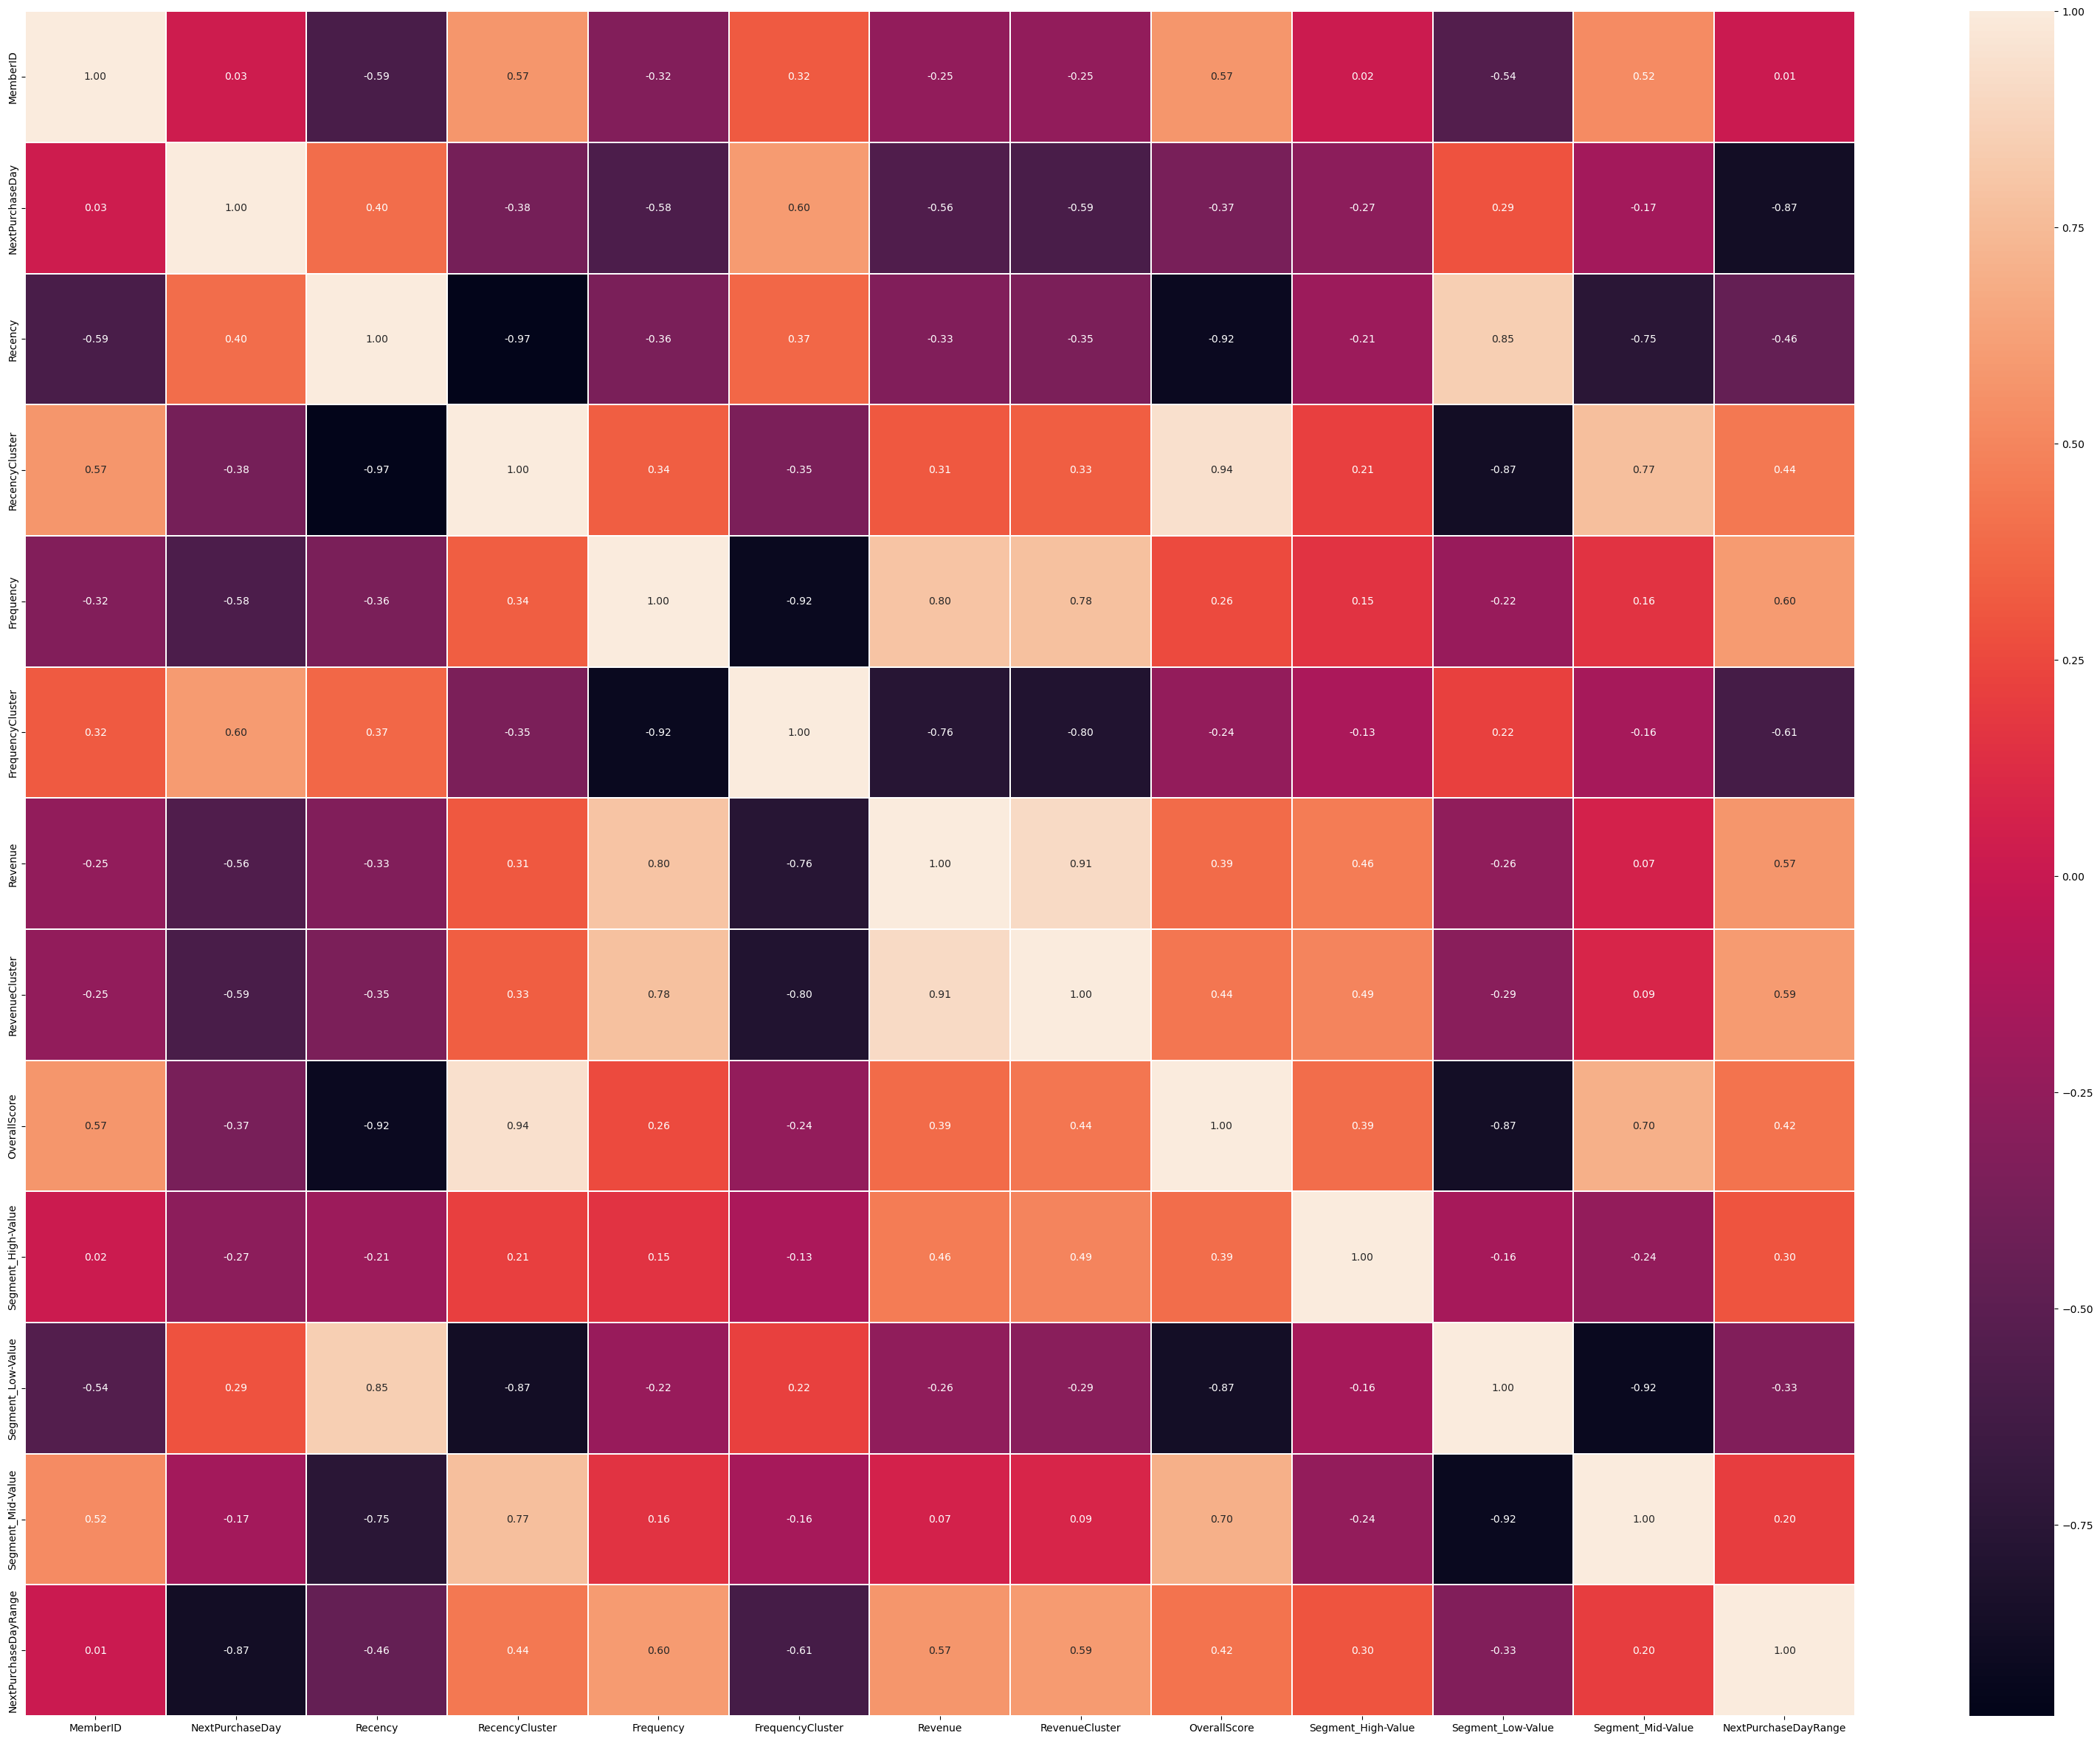

In [57]:
plt.figure(figsize = (40, 30))
sns.heatmap(corr_matrix, annot = True, linewidths=0.2, fmt=".2f");

# Modeling

In [58]:
mbr_class = mbr_class.drop('NextPurchaseDay', axis=1)

In [59]:
X, y = mbr_class.drop('NextPurchaseDayRange', axis=1), mbr_class.NextPurchaseDayRange
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [60]:
# Create an array of models
models = []
models.append(("LogisticRegression", LogisticRegression()))
models.append(("GaussianNB", GaussianNB()))
models.append(("RandomForestClassifier", RandomForestClassifier()))
models.append(("SVC", SVC()))
models.append(("DecisionTreeClassifier", DecisionTreeClassifier()))
models.append(("xgb.XGBClassifier", xgb.XGBClassifier(eval_metric='mlogloss')))
models.append(("KNeighborsClassifier", KNeighborsClassifier()))

In [61]:
# Measuring the metrics of the different models

scorer = MultiScorer({'accuracy'  : (accuracy_score , {}), 
                      'f1_score'  : (f1_score       , {'pos_label': 3, 'average':'macro'}), 
                      'recall'    : (recall_score   , {'pos_label': 3, 'average':'macro'}), 
                      'precision' : (precision_score, {'pos_label': 3, 'average':'macro'})
                     })

# A dictionary for all the distinct models and their respective metrics
model_scores_dict = {'model_name' : [], 
                     'accuracy'   : [], 
                     'f1_score'   : [], 
                     'recall'     : [], 
                     'precision'  : [],
                     'time'       : []
                    }

# For each model name and model in models
for model_name, model in models: 
    
    # Add model_name to model_scores_dict 
    model_scores_dict['model_name'].append(model_name)
    #print(model_name)
    kfold = KFold(n_splits=2, random_state=24, shuffle=True)
    start = time.time()
    _ = cross_val_score(model, X_train, y_train, cv = kfold, scoring = scorer)
    cv_result = scorer.get_results()
    
    # For each metric in cv_result.keys()
    for metric_name in cv_result.keys():
        # Get the average of cv_result[metric_name]
        average_score = np.average(cv_result[metric_name])
        # Update model_scores_dict with average_score for model_name
        model_scores_dict[metric_name].append(average_score)
        #print('%s : %f' %(metric_name, average_score))

    model_scores_dict['time'].append((time.time() - start))
    #print('time : ', time.time() - start, '\n\n')
        
model_score_df = pd.DataFrame(model_scores_dict).set_index("model_name")
model_score_df.sort_values(by=["accuracy", "f1_score", "time"], ascending=False)

,accuracy,f1_score,recall,precision,time
model_name,,,,,
LogisticRegression,0.918121,0.839794,0.815551,0.872350,0.184730
RandomForestClassifier,0.915032,0.830670,0.810028,0.865016,2.026406
xgb.XGBClassifier,0.913233,0.828787,0.812655,0.857361,0.295722
KNeighborsClassifier,0.909554,0.822470,0.806505,0.849604,0.929542
DecisionTreeClassifier,0.909421,0.818964,0.799257,0.853507,0.112027
SVC,0.907572,0.811444,0.786958,0.854412,9.102876
GaussianNB,0.905547,0.805805,0.774870,0.856943,0.051334


In [62]:
parameter = {
    'max_depth':range(3,10,2), 
    'min_child_weight':range(1,5,2)
    }

p_grid_search = GridSearchCV(estimator = xgb.XGBClassifier(eval_metric='mlogloss'), 
                             param_grid = parameter, 
                             scoring='accuracy', 
                             n_jobs=-1, 
                             #iid=False, 
                             cv=2
                            )

p_grid_search.fit(X_train, y_train)

GridSearchCV(cv=2,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'max_depth': range(3, 10, 2),
                         'min_child_weight': range(1, 5, 2)},
             scoring='accuracy')

In [63]:
p_grid_search.best_params_, p_grid_search.best_score_

({'max_depth': 3, 'min_child_weight': 3}, 0.9369713874392658)

In [64]:
refined_xgb_model = xgb.XGBClassifier(eval_metric='logloss', 
                                      max_depth=list(p_grid_search.best_params_.values())[0]-1, 
                                      min_child_weight=list(p_grid_search.best_params_.values())[-1]+4
                                     ).fit(X_train, y_train)

print('Accuracy of XGB classifier on training set: {:.2f}'.format(refined_xgb_model.score(X_train, y_train)))
print('Accuracy of XGB classifier on test set: {:.2f}'.format(refined_xgb_model.score(X_test[X_train.columns], y_test)))

Accuracy of XGB classifier on training set: 0.94
Accuracy of XGB classifier on test set: 0.94


In [65]:
ref_xgb_pred_y = refined_xgb_model.predict(X_test)

In [66]:
log_reg_pred_y = LogisticRegression().fit(X_train, y_train).predict(X_test)

In [67]:
def get_confusion_matrix(y_test, y_pred):
    """
    Displays the confusion matrix of the input numpy arrays y_test and y_pred.
    
    INPUT: 
        y_test - A numpy array 
        y_pred - A numpy array
        
    OUTPUT:
        NoneType
    """
    
    data = {'y_Actual': y_test, 'y_Predicted': y_pred}

    df = pd.DataFrame(data, columns=['y_Actual','y_Predicted'])
    conf_matrix = pd.crosstab(df['y_Actual'], df['y_Predicted'], 
                              rownames=['Actual'], 
                              colnames=['Predicted'])
    
    sns.heatmap(conf_matrix, annot=True, fmt = "d", cmap="Spectral")
    plt.show()

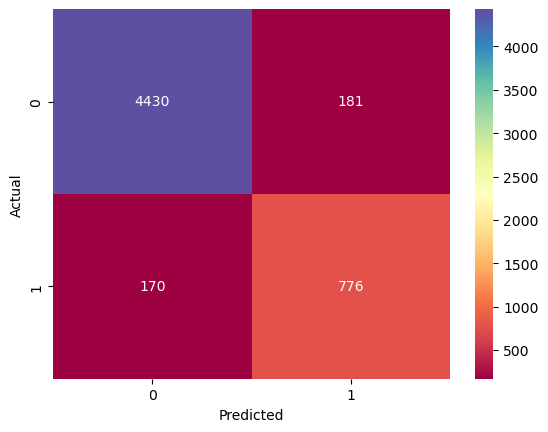

In [68]:
get_confusion_matrix(np.array(y_test), ref_xgb_pred_y)

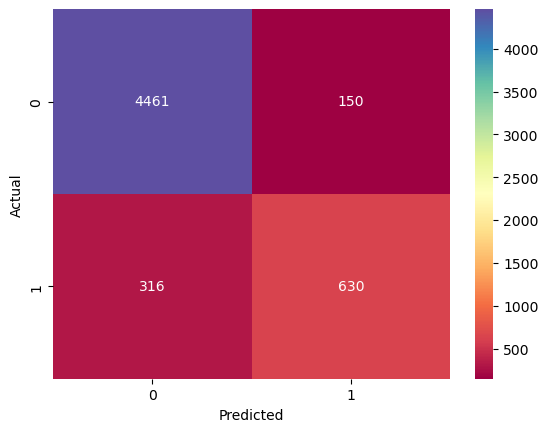

In [69]:
get_confusion_matrix(np.array(y_test), log_reg_pred_y)

# Final

In [70]:
# Define the target variable (y)
y = mbr_class['Segment_High-Value']

# Define the features (X) by dropping the ID, the target, and related segment columns
X = mbr_class.drop(columns=['MemberID', 'Segment_High-Value', 'Segment_Low-Value', 'Segment_Mid-Value'])

# Display the first few rows to verify
print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())

Features (X):
   Recency  RecencyCluster  Frequency  FrequencyCluster    Revenue  \
0       45               3          9                 2  1948000.0   
1      242               0          1                 3   263500.0   
2      211               0          2                 3   592800.0   
3      188               0          8                 2  1327200.0   
4       14               3         15                 1  8714100.0   

   RevenueCluster  OverallScore  NextPurchaseDayRange  
0               1             6                     0  
1               0             3                     0  
2               0             3                     0  
3               1             3                     0  
4               3             7                     1  

Target (y):
0    0
1    0
2    0
3    0
4    1
Name: Segment_High-Value, dtype: int32


In [71]:
# Define your features (X) and target (y)
y = mbr_class['NextPurchaseDayRange']

# Create features X by dropping the ID and the target column.
# 'NextPurchaseDay' is already gone, so we don't include it here.
X = mbr_class.drop(columns=['MemberID', 'NextPurchaseDayRange'])

# Now, rerun the train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
from xgboost import XGBRegressor

# Initialize the model. These parameters are a good starting point.
refined_xgb_model = XGBRegressor(n_estimators=500, 
                                 learning_rate=0.1, 
                                 early_stopping_rounds=10, 
                                 random_state=42, 
                                 n_jobs=-1)

print("Training the XGBoost model...")

# Train the model on your training data
# We provide the test data as an "evaluation set" for early stopping
refined_xgb_model.fit(X_train, y_train, 
                      eval_set=[(X_test, y_test)], 
                      verbose=False)

print("Model training complete.")

# You can now proceed to Step 4 to evaluate this model.

Training the XGBoost model...
Model training complete.


In [73]:
from sklearn.metrics import mean_squared_error

# Make predictions on the test set
y_pred = refined_xgb_model.predict(X_test)

# Calculate RMSE to see how far off the predictions are on average
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Model RMSE on the test set: {rmse:.4f}")

Model RMSE on the test set: 0.2289


In [74]:
# --- This is a simplified version of your notebook's logic ---
# You will need to adapt your full RFM calculation logic here.

# Load the test transaction data
df_test_trans = pd.read_csv('../dataset/test_transaction_data.csv')

# --- Apply the SAME feature engineering as in your notebook ---
# 1. Convert TransactionDatetime to datetime
df_test_trans['TransactionDatetime'] = pd.to_datetime(df_test_trans['TransactionDatetime'])

# 2. Create the final test DataFrame with unique MemberIDs
test_member_ids = pd.DataFrame(df_test_trans['MemberID'].unique(), columns=['MemberID'])

# 3. Calculate Recency, Frequency, and Revenue for the test data
#    NOTE: The 'snapshot date' for recency should be the day after the last transaction
#    in your test data.
snapshot_date_test = df_test_trans['TransactionDatetime'].max() + pd.Timedelta(days=1)

# Recency
test_recency = df_test_trans.groupby('MemberID')['TransactionDatetime'].max().reset_index()
test_recency['Recency'] = (snapshot_date_test - test_recency['TransactionDatetime']).dt.days
test_member_ids = pd.merge(test_member_ids, test_recency[['MemberID', 'Recency']], on='MemberID', how='left')

# Frequency
test_frequency = df_test_trans.groupby('MemberID').size().reset_index(name='Frequency')
test_member_ids = pd.merge(test_member_ids, test_frequency, on='MemberID', how='left')

# Revenue
df_test_trans['Revenue'] = df_test_trans['PricePerUnit'] * df_test_trans['Qty']
test_revenue = df_test_trans.groupby('MemberID')['Revenue'].sum().reset_index()
test_member_ids = pd.merge(test_member_ids, test_revenue, on='MemberID', how='left')


# --- Re-use the SAME K-Means models to create clusters ---
# It's important to use the kmeans objects you already trained in your notebook
test_member_ids['RecencyCluster'] = kmeans_recency.predict(test_member_ids[['Recency']])
test_member_ids['FrequencyCluster'] = kmeans_frequency.predict(test_member_ids[['Frequency']])
test_member_ids['RevenueCluster'] = kmeans_revenue.predict(test_member_ids[['Revenue']])

# --- Re-apply the same cluster ordering ---
test_member_ids = order_cluster(test_member_ids, 'Recency', 'RecencyCluster', False)
test_member_ids = order_cluster(test_member_ids, 'Frequency', 'FrequencyCluster', True)
test_member_ids = order_cluster(test_member_ids, 'Revenue', 'RevenueCluster', True)

# --- Calculate OverallScore ---
test_member_ids['OverallScore'] = test_member_ids['RecencyCluster'] + test_member_ids['FrequencyCluster'] + test_member_ids['RevenueCluster']

# --- Add this code to the end of Step 5 ---

# 1. Create the 'Segment' column for the test data using the same logic
test_member_ids['Segment'] = 'Low-Value'
test_member_ids.loc[test_member_ids['OverallScore'] > 4, 'Segment'] = 'Mid-Value'
test_member_ids.loc[test_member_ids['OverallScore'] > 6, 'Segment'] = 'High-Value'

# 2. Apply one-hot encoding to the test data
test_member_ids = pd.get_dummies(test_member_ids, columns=['Segment'])

# 3. Ensure the test columns match the training columns EXACTLY
# This final reindex step is robust: it adds any missing columns (e.g., if no 'High-Value'
# customers were in the test set) and fills them with 0.
final_test_features = test_member_ids.reindex(columns=X_train.columns, fill_value=0)

# Ensure the final test set has the same columns in the same order as X_train
final_test_features = test_member_ids[X_train.columns]

In [75]:
# Make predictions on the final, prepared test data
final_predictions = refined_xgb_model.predict(final_test_features)

# Round the predictions and convert them to whole numbers (integers)
final_predictions_int = final_predictions.round().astype(int)

# Load the sample submission file to get the correct format
submission_df = pd.read_csv('../submission/sample_submission.csv')

# Assign your final integer predictions to the 'next_buy' column
submission_df['next_buy'] = final_predictions_int

# Save the result to a new CSV file
submission_df.to_csv('../submission/submissionv6.csv', index=False)

print("Submission file created successfully!")
print(submission_df.head())

Submission file created successfully!
                           MemberID  next_buy
0  c2a630e3d0dc77dac0f63424a9ae1438         0
1  3ecf7484c08418953e967a20de37051b         0
2  97bbd6c99a862f20657d9b2b1c77b2c8         1
3  3ce072ff9c6f2f4b7c95dbc08324a24d         0
4  ab0b0de2a1c85a40b5d58644aef745c0         0
